In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load real Titanic Data 
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# What columns do we have?
print("Columns", df.columns.tolist())
print()

# What are the data types?
print(df.dtypes)
print()

#Basic Statistics
print(df.describe())

Columns ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1

In [6]:
print("Missing values in each columns:")
print(df.isnull().sum())
print()

print("Missing values in percentage:")
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct[missing_pct > 0 ])

Missing values in each columns:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in percentage:
Age         19.87
Cabin       77.10
Embarked     0.22
dtype: float64


In [15]:
# How many prople Survived?
print("Survived count:")
print(df["Survived"].value_counts())
print("0 = died, 1 = Survived:")
print()

# What was the survival rate?
survival_rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")
print()

# Did women survive more than man?
print("Survival rate by gender:")
print(df.groupby("Sex")["Survived"].mean() * 100)
print()

# Which passenger class survived most?
print("Survivlal rate by class:")
print(df.groupby("Pclass")["Survived"].mean() * 100)
print()

Survived count:
Survived
0    549
1    342
Name: count, dtype: int64
0 = died, 1 = Survived:

Overall survival rate: 38.4%

Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survivlal rate by class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64



In [19]:
# Average age of survivors and non-survivors
print("Average Age:")
print(df.groupby("Survived")["Age"].mean())
print()

# How much did people pay on average per class?
print("Average fare by class:")
print(df.groupby("Pclass")["Fare"].mean().round(2))
print()

# Where did most passengers boared?
print("Passengers by boarding point:")
print(df["Embarked"].value_counts())
print("S=Southampton, C=Cherbourg, Q=Queenstown")


Average Age:
Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

Average fare by class:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

Passengers by boarding point:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
S=Southampton, C=Cherbourg, Q=Queenstown


In [29]:
print("Before Fixing:")
print(df.isnull().sum())

# Fix the Age - fill with median(better than mean for age)
df["Age"] = df["Age"].fillna(df["Age"].median())

#Fix Embarked
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin
df.drop("Cabin", axis=1, inplace=True)

print("After Fixing:")
print(df.isnull().sum())

Before Fixing:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64
After Fixing:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


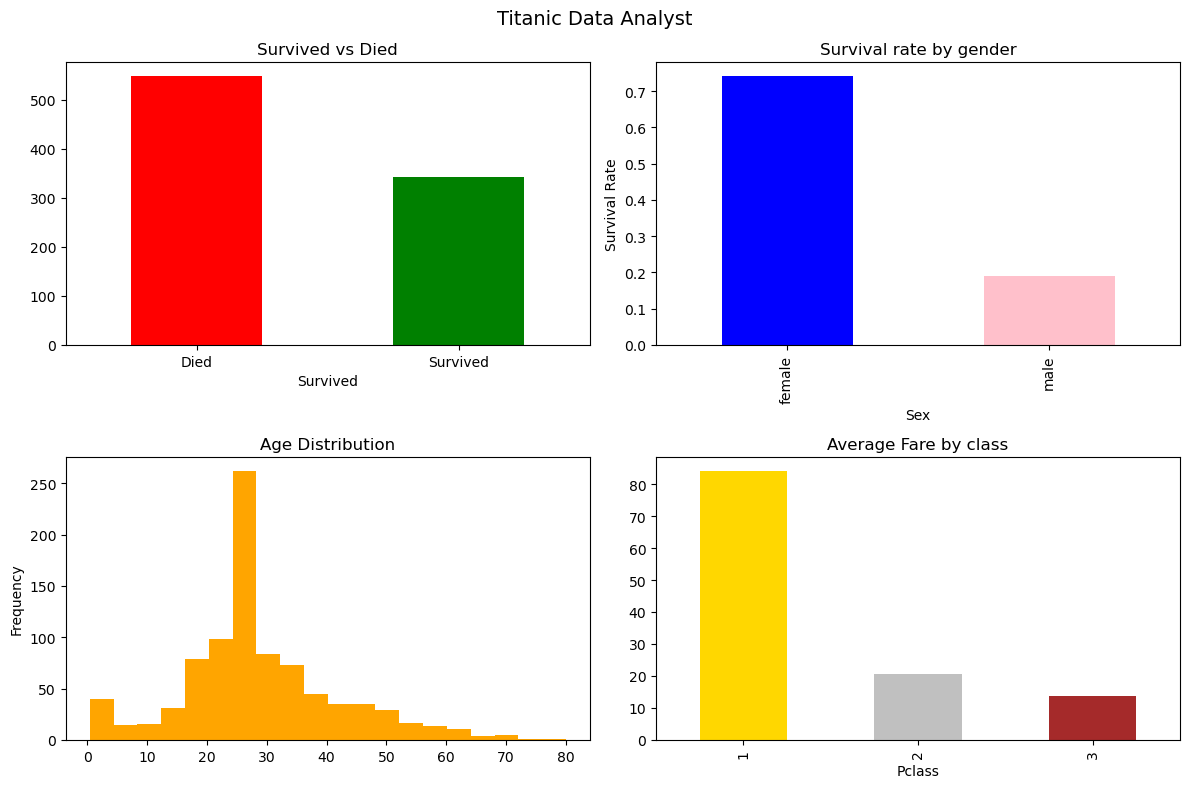

Chart Created!


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
fig.suptitle("Titanic Data Analyst", fontsize=14)

#Chart-1 : Survival Count
df["Survived"].value_counts().plot(kind="bar", ax=axes[0,0], color=["red","green"], title= "Survived vs Died")
axes[0,0].set_xticklabels(["Died","Survived"], rotation=0)

#Chart-2 : survival by gender
df.groupby("Sex")["Survived"].mean().plot(kind="bar", ax=axes[0,1], color=["blue","pink"], title= "Survival rate by gender")
axes[0,1].set_ylabel("Survival Rate")

#Chart-3 : age distribution
df["Age"].plot(kind="hist", ax=axes[1,0], bins=20, title="Age Distribution", color="orange" )

#Chart-4 : Fare by class
df.groupby("Pclass")["Fare"].mean().plot(kind="bar", ax=axes[1,1], color=["gold", "silver", "brown"], title="Average Fare by class")

plt.tight_layout()
plt.show()

print("Chart Created!")

In [43]:
# Write your own 3 findings from the data
print("MY FINDINGS FROM TITANIC DATA:")
print()
print(f"1. Survival rate was only {df['Survived'].mean()*100:.1f}%")
print(f"2. Women survived at {df[df['Sex']=='female']['Survived'].mean()*100:.1f}% vs men at {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"3. First class survival rate: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"   Third class survival rate: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print()
print("Conclusion: Being a woman in first class gave the best chance of survival!")

MY FINDINGS FROM TITANIC DATA:

1. Survival rate was only 38.4%
2. Women survived at 74.2% vs men at 18.9%
3. First class survival rate: 63.0%
   Third class survival rate: 24.2%

Conclusion: Being a woman in first class gave the best chance of survival!
